
# FinTrust Bank – Week 2 Exploratory Data Analysis

**AnalystLab Africa Experience Lab Internship – Data Analytics Track**  
**Student:** Tsholofelo Hope Motlhatlhedi  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

---

## 1. Objective

This notebook performs exploratory data analysis (EDA) on the FinTrust customer and transaction datasets.

The analysis investigates:

- Customer segments
- Transaction types
- Transaction amounts
- Transaction channels
- Transaction status
- International transactions
- Customer behaviour
- Risk-review patterns

The purpose of EDA is to understand the structure and patterns in the data before moving to more advanced analysis or dashboard development.

At least five meaningful visualizations are included. For each important visualization, the notebook explains:

1. **What the visual shows**
2. **Why it is important**
3. **What business insight can be derived**

> **Important:** The dataset covers transactions from January to March 2026. `Risk_Review_Flag` is treated as a supplied analytical label and is not automatically interpreted as proof of fraud or suspicious activity.



## 2. Import Libraries

The required Python libraries are imported below.

- **Pandas** is used for data loading, cleaning and analysis.
- **NumPy** is used for numerical operations.
- **Matplotlib** is used for plotting.
- **Seaborn** is used to create statistical visualizations.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display more columns when viewing DataFrames.
pd.set_option("display.max_columns", None)

# Use a clean Seaborn theme for the exploratory charts.
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.



## 3. Load the FinTrust Data

Two Excel files are required:

1. `FinTrust_Customer_Data(1).xlsx`
2. `FinTrust_Transaction_Data(2).xlsx`

The code first checks the working directory and then falls back to the file paths used during the analysis environment.

If this notebook is moved to another computer, place the two Excel files in the same folder as the notebook and update the paths below if necessary.


In [2]:

from pathlib import Path

# File locations used for this analysis.
customer_file = Path("FinTrust_Customer_Data(1).xlsx")
transaction_file = Path("FinTrust_Transaction_Data(2).xlsx")

# Fallback paths used in the original analysis environment.
if not customer_file.exists():
    customer_file = Path("/mnt/data/FinTrust_Customer_Data(1).xlsx")

if not transaction_file.exists():
    transaction_file = Path("/mnt/data/FinTrust_Transaction_Data(2).xlsx")

# Load the Excel files into Pandas DataFrames.
customer_df = pd.read_excel(customer_file)
transaction_df = pd.read_excel(transaction_file)

print("Customer data shape:", customer_df.shape)
print("Transaction data shape:", transaction_df.shape)


Customer data shape: (1500, 12)
Transaction data shape: (12000, 11)



### Initial Data Profile

The supplied customer dataset contains **1,500 customer records and 12 columns**.

The supplied transaction dataset contains **12,000 transaction records and 11 columns**.

The customer table contains demographic, account and digital-engagement information. The transaction table contains transaction date/time, type, amount, channel, device, location, transaction status, international status and risk-review information.


In [3]:

# View the first five records from each dataset.
display(customer_df.head())
display(transaction_df.head())

# Display the column names.
print("Customer columns:")
print(customer_df.columns.tolist())

print("\nTransaction columns:")
print(transaction_df.columns.tolist())


,Customer_ID,Customer_Name,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-C00001,Ibrahim Adeyemi,56,Male,Lagos,Premium,Savings,55,84.9,500k-999k,Mobile App,Active
1,FT-C00002,Yusuf Mohammed,46,Male,Kano,Everyday,Current,79,50.7,500k-999k,Mobile App,Active
2,FT-C00003,Emeka Adeyemi,32,Female,Port Harcourt,Everyday,Savings,43,56.1,1m+,Mobile App,Active
3,FT-C00004,David Williams,60,Female,Benin City,Premium,Premium,44,54.0,500k-999k,Mobile App,Dormant
4,FT-C00005,Blessing Adeyemi,25,Male,Kaduna,Premium,Savings,68,85.1,500k-999k,Mobile App,Active


,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag
0,FT-T000001,FT-C01135,2026-01-01 00:00:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes
1,FT-T000002,FT-C00428,2026-01-01 00:10:00,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes
2,FT-T000003,FT-C00469,2026-01-01 00:21:00,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No
3,FT-T000004,FT-C01015,2026-01-01 00:32:00,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,No
4,FT-T000005,FT-C00870,2026-01-01 00:43:00,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,No


Customer columns:
['Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'Customer_Segment', 'Account_Type', 'Tenure_Months', 'Digital_Engagement_Score', 'Monthly_Income_Band', 'Preferred_Channel', 'Account_Status']

Transaction columns:
['Transaction_ID', 'Customer_ID', 'Transaction_DateTime', 'Transaction_Type', 'Amount_NGN', 'Channel', 'Device_Type', 'Location', 'International_Transaction', 'Transaction_Status', 'Risk_Review_Flag']



## 4. Data Preparation and Quality Checks

Before analysing the data, basic checks are performed for:

- Data types
- Missing values
- Duplicate records
- Date formatting
- Numerical transaction amounts
- Relationship between customers and transactions

These checks reduce the risk of producing misleading results from incorrectly formatted or incomplete data.


In [4]:

# Make copies so the original imported DataFrames remain available.
customers = customer_df.copy()
transactions = transaction_df.copy()

# Convert transaction date/time to a proper datetime field.
transactions["Transaction_DateTime"] = pd.to_datetime(
    transactions["Transaction_DateTime"],
    errors="coerce"
)

# Make sure transaction amounts are numeric.
transactions["Amount_NGN"] = pd.to_numeric(
    transactions["Amount_NGN"],
    errors="coerce"
)

print("Customer data types:")
display(customers.dtypes.to_frame("Data Type"))

print("\nTransaction data types:")
display(transactions.dtypes.to_frame("Data Type"))


Customer data types:


,Data Type
Customer_ID,object
Customer_Name,object
Age,int64
Gender,object
City,object
Customer_Segment,object
Account_Type,object
Tenure_Months,int64
Digital_Engagement_Score,float64
Monthly_Income_Band,object



Transaction data types:


,Data Type
Transaction_ID,object
Customer_ID,object
Transaction_DateTime,datetime64[ns]
Transaction_Type,object
Amount_NGN,float64
Channel,object
Device_Type,object
Location,object
International_Transaction,object
Transaction_Status,object


In [5]:

# Missing-value check
missing_summary = pd.DataFrame({
    "Customer_Missing": customers.isna().sum(),
    "Transaction_Missing": transactions.isna().sum()
}).fillna(0).astype(int)

display(missing_summary)

# Duplicate checks
print("Duplicate customer records:", customers.duplicated().sum())
print("Duplicate transaction records:", transactions.duplicated().sum())

# Check whether every transaction Customer_ID exists in the customer dataset.
unmatched_customers = (
    transactions.loc[
        ~transactions["Customer_ID"].isin(customers["Customer_ID"]),
        "Customer_ID"
    ]
    .nunique()
)

print("Transaction Customer_IDs without a matching customer:", unmatched_customers)

# Date range
print(
    "Transaction date range:",
    transactions["Transaction_DateTime"].min(),
    "to",
    transactions["Transaction_DateTime"].max()
)


,Customer_Missing,Transaction_Missing
Account_Status,0,0
Account_Type,0,0
Age,0,0
Amount_NGN,0,0
Channel,0,0
City,0,0
Customer_ID,0,0
Customer_Name,0,0
Customer_Segment,0,0
Device_Type,0,96


Duplicate customer records: 0
Duplicate transaction records: 0
Transaction Customer_IDs without a matching customer: 0
Transaction date range: 2026-01-01 00:00:00 to 2026-03-31 23:59:00



### Data Quality Observation

The transaction dataset contains missing values in **Device_Type** and **Location**. These fields should therefore be handled carefully when producing device- or location-specific analysis.

The analysis does not replace missing device or location values with invented values. Instead, charts involving these fields exclude missing observations and clearly state this limitation.

The transaction Customer_ID values match the customer dataset, allowing the two datasets to be joined for customer-behaviour analysis.



# 5. Exploratory Analysis

The following sections investigate the main business areas requested in the Week 2 assignment.



## Visualization 1 – Customer Segment Distribution

### What does the visual show?
This chart shows the number of customers belonging to each FinTrust customer segment.

### Why is it important?
Understanding the size of each segment provides context for later comparisons. A segment with more customers can naturally generate more transactions simply because it has a larger customer population.

### What business insight can be derived?
The Everyday segment is the largest customer segment in the supplied dataset. This means its transaction volume should be interpreted alongside its larger customer population rather than automatically assuming that each individual customer is more active.


ValueError: Invalid RGBA argument: None

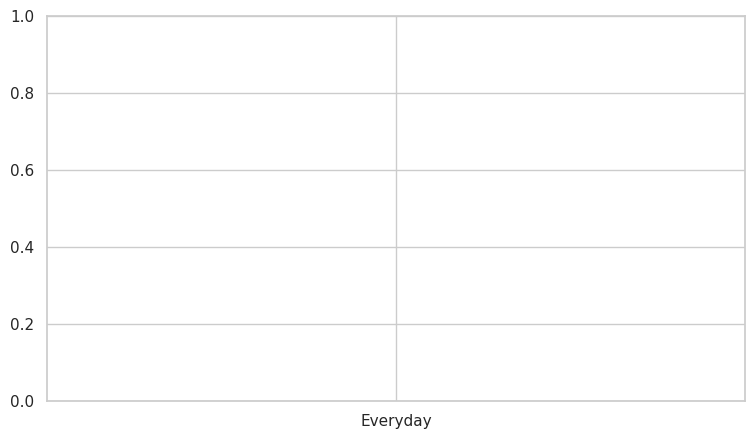

In [6]:

segment_counts = customers["Customer_Segment"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.bar(segment_counts.index, segment_counts.values)

plt.title("FinTrust Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

# Add data labels to make the chart easier to interpret.
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

display(
    segment_counts.rename("Customers").to_frame()
)



## Visualization 2 – Transaction Type Volume and Value

### What does the visual show?
This analysis compares transaction types by both transaction count and total transaction value.

### Why is it important?
Transaction count shows how frequently a service is used, while total value shows the financial value moving through that transaction type. Looking at both prevents a high-volume, low-value service from being confused with a lower-volume, high-value service.

### What business insight can be derived?
Transfers generate the highest total transaction value in the dataset. Deposits have a lower transaction count than transfers but a high average transaction amount, showing why transaction volume and transaction value should be analysed separately.


In [ ]:

type_summary = (
    transactions
    .groupby("Transaction_Type")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Value_NGN=("Amount_NGN", "sum"),
        Average_Value_NGN=("Amount_NGN", "mean")
    )
    .sort_values("Total_Value_NGN", ascending=False)
)

display(type_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Transaction volume
volume_plot = type_summary.sort_values("Transaction_Count", ascending=False)
axes[0].barh(volume_plot.index, volume_plot["Transaction_Count"])
axes[0].set_title("Transaction Volume by Transaction Type")
axes[0].set_xlabel("Number of Transactions")
axes[0].set_ylabel("Transaction Type")

# Total transaction value
value_plot = type_summary.sort_values("Total_Value_NGN", ascending=False)
axes[1].barh(value_plot.index, value_plot["Total_Value_NGN"] / 1_000_000)
axes[1].set_title("Total Transaction Value by Transaction Type")
axes[1].set_xlabel("Total Value (NGN millions)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()



## Visualization 3 – Distribution of Transaction Amounts

### What does the visual show?
The histogram shows how individual transaction amounts are distributed. A boxplot is also included to make the median, spread and unusually large observations easier to identify.

### Why is it important?
Transaction amounts are often highly uneven. A small number of large transactions can substantially increase the average. Examining the distribution helps determine whether the mean is representative of a typical transaction.

### What business insight can be derived?
The transaction amounts are strongly right-skewed, meaning many transactions are relatively small while a smaller number of transactions have much larger values. This supports reporting the median alongside the mean when describing typical transaction behaviour.


In [ ]:

amounts = transactions["Amount_NGN"].dropna()

mean_amount = amounts.mean()
median_amount = amounts.median()

fig, axes = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={"height_ratios": [3, 1]})

# Histogram
sns.histplot(
    amounts,
    bins=50,
    kde=True,
    ax=axes[0]
)
axes[0].axvline(
    mean_amount,
    linestyle="--",
    label=f"Mean: NGN {mean_amount:,.2f}"
)
axes[0].axvline(
    median_amount,
    linestyle=":",
    label=f"Median: NGN {median_amount:,.2f}"
)
axes[0].set_title("Distribution of FinTrust Transaction Amounts")
axes[0].set_xlabel("Transaction Amount (NGN)")
axes[0].set_ylabel("Number of Transactions")
axes[0].legend()

# Boxplot
sns.boxplot(
    x=amounts,
    ax=axes[1]
)
axes[1].set_title("Transaction Amount Boxplot")
axes[1].set_xlabel("Transaction Amount (NGN)")

plt.tight_layout()
plt.show()

print(f"Mean transaction amount:   NGN {mean_amount:,.2f}")
print(f"Median transaction amount: NGN {median_amount:,.2f}")
print(f"Maximum transaction amount: NGN {amounts.max():,.2f}")



## Visualization 4 – Transaction Channel Usage

### What does the visual show?
The chart compares the number of transactions completed through each banking channel.

### Why is it important?
Channel usage helps FinTrust understand how customers interact with the bank and where transaction activity is concentrated.

### What business insight can be derived?
The Mobile App is the most frequently used transaction channel in the dataset. This indicates that mobile digital banking is a major route through which customers perform transactions.


In [ ]:

channel_summary = (
    transactions
    .groupby("Channel")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Unique_Customers=("Customer_ID", "nunique"),
        Total_Value_NGN=("Amount_NGN", "sum"),
        Average_Value_NGN=("Amount_NGN", "mean")
    )
    .sort_values("Transaction_Count", ascending=False)
)

display(channel_summary.round(2))

plt.figure(figsize=(10, 5))
bars = plt.bar(channel_summary.index, channel_summary["Transaction_Count"])

plt.title("Transaction Volume by Banking Channel")
plt.xlabel("Transaction Channel")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()



## Visualization 5 – Transaction Status

### What does the visual show?
This chart shows the proportion of transactions by transaction status.

### Why is it important?
Transaction status is a direct indicator of transaction completion and operational performance. Monitoring failed and reversed transactions can help identify areas requiring further investigation.

### What business insight can be derived?
Most transactions are successful, while a smaller proportion are failed or reversed. The overall success rate in the dataset is approximately 90.47%. Failed and reversed transactions together account for the remaining activity and provide an operational area for further analysis.


In [ ]:

status_counts = transactions["Transaction_Status"].value_counts()

status_percent = (
    transactions["Transaction_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

status_table = pd.DataFrame({
    "Transactions": status_counts,
    "Percentage": status_percent
})

display(status_table)

plt.figure(figsize=(8, 5))
bars = plt.bar(status_counts.index, status_counts.values)

plt.title("Transaction Status Distribution")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()



## Visualization 6 – International vs Domestic Transactions

### What does the visual show?
This comparison shows transaction volume and transaction value for international versus non-international transactions.

### Why is it important?
International transactions can have different operational, compliance and risk characteristics from domestic transactions. Comparing both count and value helps distinguish frequency from financial exposure.

### What business insight can be derived?
The supplied data allows FinTrust to quantify the relative contribution of international transactions to overall activity. This can support further monitoring of international transaction patterns and risk-review behaviour.


In [ ]:

international_summary = (
    transactions
    .groupby("International_Transaction")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Unique_Customers=("Customer_ID", "nunique"),
        Total_Value_NGN=("Amount_NGN", "sum"),
        Average_Value_NGN=("Amount_NGN", "mean")
    )
)

international_summary["Transaction_Share_Pct"] = (
    international_summary["Transaction_Count"]
    / international_summary["Transaction_Count"].sum()
    * 100
)

international_summary["Value_Share_Pct"] = (
    international_summary["Total_Value_NGN"]
    / international_summary["Total_Value_NGN"].sum()
    * 100
)

display(international_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    international_summary.index.astype(str),
    international_summary["Transaction_Count"]
)
axes[0].set_title("Transaction Count: International vs Domestic")
axes[0].set_xlabel("International Transaction")
axes[0].set_ylabel("Number of Transactions")

axes[1].bar(
    international_summary.index.astype(str),
    international_summary["Total_Value_NGN"] / 1_000_000
)
axes[1].set_title("Transaction Value: International vs Domestic")
axes[1].set_xlabel("International Transaction")
axes[1].set_ylabel("Total Value (NGN millions)")

plt.tight_layout()
plt.show()



## Visualization 7 – Customer Behaviour: Digital Engagement vs Transaction Activity

### What does the visual show?
Each point represents a customer. The horizontal axis shows the customer's Digital Engagement Score and the vertical axis shows the number of transactions completed during the observation period. Points are grouped by customer segment.

### Why is it important?
This helps investigate whether customers with higher recorded digital engagement also tend to transact more frequently.

### What business insight can be derived?
The plot allows FinTrust to identify whether transaction activity is concentrated among highly digitally engaged customers and whether the relationship differs across customer segments. The relationship should be interpreted as an association rather than proof that engagement causes higher transaction activity.


In [ ]:

customer_activity = (
    transactions
    .groupby("Customer_ID")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Transaction_Value_NGN=("Amount_NGN", "sum"),
        Average_Transaction_Value_NGN=("Amount_NGN", "mean")
    )
    .reset_index()
)

customer_activity = customer_activity.merge(
    customers[
        [
            "Customer_ID",
            "Customer_Segment",
            "Age",
            "Digital_Engagement_Score",
            "Monthly_Income_Band",
            "Account_Type"
        ]
    ],
    on="Customer_ID",
    how="left"
)

display(
    customer_activity.groupby("Customer_Segment")
    .agg(
        Customers=("Customer_ID", "nunique"),
        Avg_Transactions=("Transaction_Count", "mean"),
        Avg_Total_Value=("Total_Transaction_Value_NGN", "mean"),
        Avg_Engagement=("Digital_Engagement_Score", "mean")
    )
    .round(2)
)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=customer_activity,
    x="Digital_Engagement_Score",
    y="Transaction_Count",
    hue="Customer_Segment",
    alpha=0.65
)

plt.title("Customer Digital Engagement vs Transaction Activity")
plt.xlabel("Digital Engagement Score")
plt.ylabel("Number of Transactions")
plt.legend(title="Customer Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

correlation = customer_activity[
    ["Digital_Engagement_Score", "Transaction_Count"]
].corr().iloc[0, 1]

print(f"Pearson correlation between digital engagement and transaction count: {correlation:.3f}")



## Visualization 8 – Risk-Review Patterns by Transaction Type

### What does the visual show?
The chart shows the percentage of transactions flagged for risk review within each transaction type.

### Why is it important?
A risk-review rate allows FinTrust to compare transaction categories fairly, even when the categories have different transaction volumes.

### What business insight can be derived?
Transfer transactions have the highest risk-review rate among the transaction types in the supplied dataset, followed by cash withdrawals. This identifies transaction categories that could be examined more closely in a deeper risk analysis.

> **Caution:** A risk-review flag is an analytical label in this dataset. A higher rate does not by itself mean that the transactions are fraudulent or that the transaction type causes risk.


In [ ]:

risk_by_type = (
    transactions
    .groupby("Transaction_Type")
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Risk_Review_Count=("Risk_Review_Flag", lambda x: (x == "Yes").sum())
    )
)

risk_by_type["Risk_Review_Rate_Pct"] = (
    risk_by_type["Risk_Review_Count"]
    / risk_by_type["Total_Transactions"]
    * 100
)

risk_by_type = risk_by_type.sort_values(
    "Risk_Review_Rate_Pct",
    ascending=False
)

display(risk_by_type.round(2))

plt.figure(figsize=(10, 6))
bars = plt.barh(
    risk_by_type.index,
    risk_by_type["Risk_Review_Rate_Pct"]
)

plt.title("Risk-Review Rate by Transaction Type")
plt.xlabel("Risk-Review Rate (%)")
plt.ylabel("Transaction Type")

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.2f}%",
        va="center",
        ha="left"
    )

plt.tight_layout()
plt.show()



## 6. Additional Risk-Review Comparisons

The assignment specifically asks for risk-review patterns. In addition to transaction type, the following tables compare risk-review rates by channel and customer segment.

This helps separate a transaction-type pattern from a channel- or customer-segment pattern.


In [ ]:

# Risk-review rate by channel
risk_by_channel = (
    transactions
    .groupby("Channel")
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Risk_Review_Count=("Risk_Review_Flag", lambda x: (x == "Yes").sum())
    )
)

risk_by_channel["Risk_Review_Rate_Pct"] = (
    risk_by_channel["Risk_Review_Count"]
    / risk_by_channel["Total_Transactions"]
    * 100
)

risk_by_channel = risk_by_channel.sort_values(
    "Risk_Review_Rate_Pct",
    ascending=False
)

# Risk-review rate by customer segment
risk_segment = transactions.merge(
    customers[["Customer_ID", "Customer_Segment"]],
    on="Customer_ID",
    how="left"
)

risk_by_segment = (
    risk_segment
    .groupby("Customer_Segment")
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Risk_Review_Count=("Risk_Review_Flag", lambda x: (x == "Yes").sum())
    )
)

risk_by_segment["Risk_Review_Rate_Pct"] = (
    risk_by_segment["Risk_Review_Count"]
    / risk_by_segment["Total_Transactions"]
    * 100
)

risk_by_segment = risk_by_segment.sort_values(
    "Risk_Review_Rate_Pct",
    ascending=False
)

print("Risk-review rate by channel:")
display(risk_by_channel.round(2))

print("Risk-review rate by customer segment:")
display(risk_by_segment.round(2))



## 7. Overall EDA Findings

Based on the supplied FinTrust data, the main exploratory findings are:

### Customer segments
The **Everyday** segment is the largest customer segment, with 711 customers. Segment size is important when comparing transaction volumes because larger populations naturally have more opportunities to transact.

### Transaction types
**Transfer** has the highest total transaction value at approximately **NGN 237.92 million**. **Deposit** has the highest average transaction value at approximately **NGN 98,633.33**.

### Transaction amounts
Transaction values are right-skewed. The mean transaction value is approximately **NGN 46,706.45**, while the median is approximately **NGN 10,305.94**. The difference indicates that larger transactions pull the mean upward.

### Transaction channels
The **Mobile App** is the most frequently used channel, with **5,102 transactions**, making it the main transaction channel in the dataset.

### Transaction status
Approximately **90.47%** of transactions are successful. Failed and reversed transactions form a smaller but important operational category for further investigation.

### International transactions
The international/domestic comparison shows the relative volume and value contribution of international transactions. This can support further compliance and risk analysis.

### Customer behaviour
Customer-level analysis shows that transaction activity varies across customer segments. Everyday customers have the largest overall transaction volume because they are the largest segment, while Student customers have the highest average number of transactions per customer at approximately **8.23**.

### Risk-review patterns
Risk-review rates vary across transaction types, channels and customer segments. **Transfer** has the highest risk-review rate among transaction types at approximately **28.49%**. This is an association in the dataset and should not be interpreted as causation or as proof of fraudulent activity.

---

## 8. Limitations of the Analysis

The following limitations should be considered when interpreting the findings:

1. The transaction data covers only **January to March 2026**, so the results describe this observation period rather than a full year.
2. **96 Device_Type values** are missing, so device-level analysis excludes those records.
3. **96 Location values** are missing, so location-level analysis excludes those records.
4. The supplied geographic analysis is limited to the locations represented in the dataset.
5. Monthly income is provided as an **income band**, not an exact numerical income value. The analysis therefore treats it as a categorical/ordinal field.
6. Risk-review flags are treated as supplied labels and do not independently establish fraud or suspicious behaviour.
7. Correlation and visual patterns show associations; they do not establish causation.

---

## 9. Conclusion

The exploratory analysis provides a structured view of FinTrust customer and transaction behaviour.

The strongest patterns are high digital activity, heavy use of the Mobile App, high transaction value concentrated in transfers, a strongly right-skewed transaction amount distribution, and measurable differences in risk-review rates across transaction types and channels.

These findings can be used as a foundation for the next stage of analysis, including more detailed statistical analysis, dashboard development and business recommendations.



## End of Notebook

**Deliverable:** `FinTrust_Week2_Data_Analysis.ipynb`

All major analysis steps, visualizations, comments, interpretations and limitations are contained in this notebook.
